# MNIST CNN — Single Node Baseline
This notebook trains a CNN on MNIST on a single machine.
This is the baseline that our distributed Parameter Server system should replicate across multiple nodes.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 1. Download MNIST
PyTorch downloads and caches MNIST automatically on first run.
In our distributed system, each worker node does exactly this independently —
the orchestrator never sends raw image data over the network.


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")


100.0%
100.0%
100.0%
100.0%

Training samples : 60000
Test samples     : 10000


## 2. Simulate Data Sharding
In our distributed system, the orchestrator assigns each worker a (start_index, end_index) range.
Here we simulate one worker receiving shard 0 out of 4 total shards.


In [6]:
def create_shard(dataset, shard_index, total_shards):
    """
    Mimics what a worker node does after receiving its assignment.
    The orchestrator only sends shard_index and total_shards — not the data itself.
    """
    dataset_size = len(dataset)
    shard_size   = dataset_size // total_shards
    start_idx    = shard_index * shard_size
    end_idx      = start_idx + shard_size
    print(f"Shard {shard_index}/{total_shards}: indices {start_idx} to {end_idx} ({shard_size} samples)")
    return Subset(dataset, range(start_idx, end_idx))

# Simulate this node being assigned shard 0 of 4
TOTAL_SHARDS = 4
SHARD_INDEX  = 0

my_shard = create_shard(train_dataset, SHARD_INDEX, TOTAL_SHARDS)
train_loader = DataLoader(my_shard,    batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


Shard 0/4: indices 0 to 15000 (15000 samples)


## 3. Peek at the Data

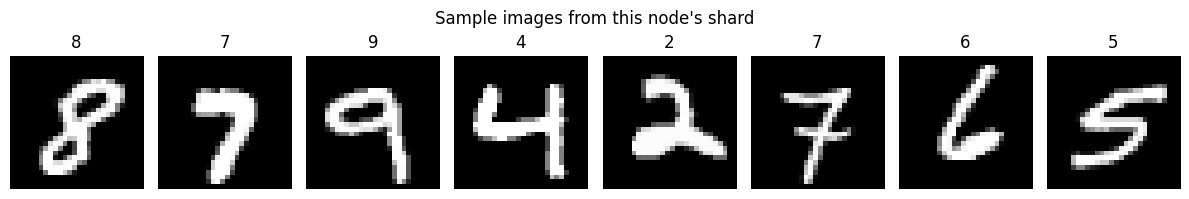

In [7]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(str(labels[i].item()))
    ax.axis("off")
plt.suptitle("Sample images from this node's shard")
plt.tight_layout()
plt.show()


## 4. Define the CNN Model
Two convolutional blocks followed by a small classifier head.
This same architecture is used on every worker node and on the orchestrator server.


In [8]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            # Block 1: 1x28x28 → 32x14x14
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 32x14x14 → 64x7x7
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)  # 10 classes: digits 0-9
        )

    def forward(self, x):
        return self.classifier(self.conv_layers(x))

model = MNISTNet().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


MNISTNet(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 421,642


## 5. Training Loop
In the distributed system, this is what each worker runs each round.
The key difference: workers do NOT call optimizer.step() themselves.
They compute gradients and send them back to the orchestrator, which runs the optimizer.

Here we run the full loop locally for baseline comparison.


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    In the distributed system this is what one worker does per round,
    except it stops before optimizer.step() and sends param.grad to the orchestrator.
    """
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()       # computes gradients
        optimizer.step()      # orchestrator does this in distributed version

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs     = model(images)
            loss        = criterion(outputs, labels)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total


## 6. Run Training
Training for 5 epochs on one shard. Expect ~97-98% test accuracy on the full dataset.
On just one shard (25% of data) accuracy will be slightly lower but should still converge cleanly.


In [10]:
NUM_EPOCHS = 5
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss:.4f}  acc: {train_acc:.3f} | "
          f"Test  loss: {test_loss:.4f}  acc: {test_acc:.3f}")


Epoch 1/5 | Train loss: 0.4937  acc: 0.846 | Test  loss: 0.0956  acc: 0.972
Epoch 2/5 | Train loss: 0.1602  acc: 0.953 | Test  loss: 0.0606  acc: 0.980
Epoch 3/5 | Train loss: 0.1110  acc: 0.966 | Test  loss: 0.0575  acc: 0.981
Epoch 4/5 | Train loss: 0.0897  acc: 0.972 | Test  loss: 0.0498  acc: 0.985
Epoch 5/5 | Train loss: 0.0819  acc: 0.974 | Test  loss: 0.0447  acc: 0.984


## 7. Training Accuracy Curves

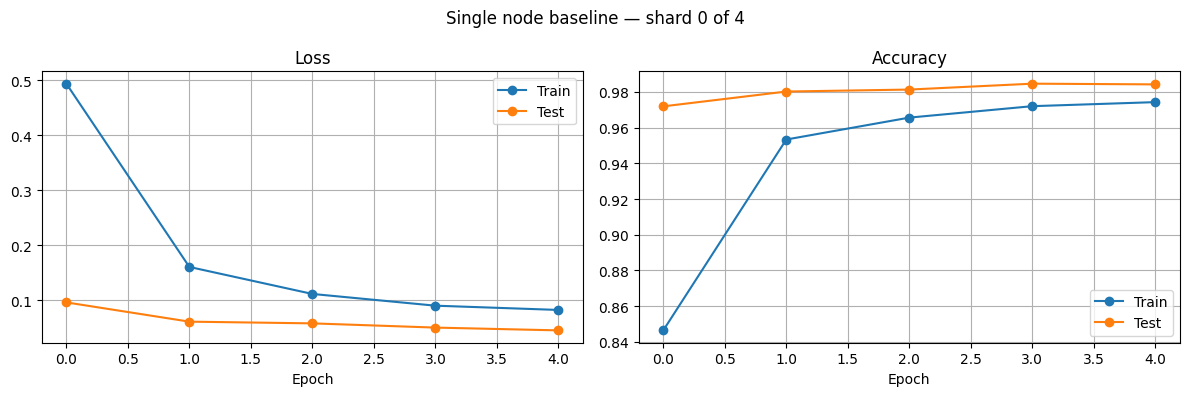

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train", marker="o")
ax1.plot(test_losses,  label="Test",  marker="o")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label="Train", marker="o")
ax2.plot(test_accs,  label="Test",  marker="o")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(True)

plt.suptitle(f"Single node baseline — shard {SHARD_INDEX} of {TOTAL_SHARDS}")
plt.tight_layout()
plt.show()


## 8. Checkpoint Simulation
The orchestrator saves model weights after each round.
This is what gets written to disk and reloaded on server restart.


In [13]:
import os

CHECKPOINT_PATH = "./checkpoint.pt"

# Save (orchestrator does this after aggregating gradients)
torch.save({
    "round"      : NUM_EPOCHS,
    "model_state": model.state_dict(),
    "optim_state": optimizer.state_dict(),
}, CHECKPOINT_PATH)

print(f"Checkpoint saved to {CHECKPOINT_PATH}")
print(f"File size: {os.path.getsize(CHECKPOINT_PATH) / 1024:.1f} KB")

# Reload (orchestrator does this on restart)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optim_state"])
print(f"Checkpoint loaded — resuming from round {checkpoint['round']}")


Checkpoint saved to ./checkpoint.pt
File size: 4951.1 KB
Checkpoint loaded — resuming from round 5
